In [1]:
from typing_extensions import TypedDict
from typing import Annotated, Literal, List, Dict, Any
from operator import add
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langchain.chat_models import init_chat_model




llm = init_chat_model("openai:gpt-4o")


In [2]:
class State(TypedDict):
    ask: str
    needs: List[str]          
    codes: Annotated[List[Dict[str, Any]], add]  
    passed: bool     
    final_code: str
    
   

In [3]:
def analyze_ask(state:State):
    response = llm.invoke(
        f"어떤 종류의 코딩이 필요한지 분석해줘:{state['ask']}"
    )
    return {
        "needs":[
            {
                "need":response.content,                
    }
    ]
    }

def simple_coder(state:State):
    response = llm.invoke(
        f"필요한 코딩을 간단하게 구현해줘:{state['needs']}"
    )
    return {
        "codes":[
            {
                "code":response.content,                
    }
    ]
    }
def do_coder(state:State):
    response = llm.invoke(
        f"필요한 코딩을 꼭 실행이 되게 구현해줘:{state['needs']}"
    )
    return {
        "codes":[
            {
                "code":response.content,                
    }
    ]
    }
def easy_coder(state:State):
    response = llm.invoke(
        f"필요한 코딩을 누구나 이해하기 쉽게 구현해줘:{state['needs']}"
    )
    return {
        "codes":[
            {
                "code":response.content,                
    }
    ]
    }

def collect(state: State):
    return {}

def has_three_codes(state: State) -> bool:
    return len(state["codes"]) >= 3

def evaluator(state : State):
    response = llm.invoke(f"""출력된 3개 코딩을 평가해줘, 
                          평가항목은 1. 간단하게 만들었는지 2. 작동이 되는지, 3. 누구나 이해할 수 있는지 
                          이 세가지 평가항목을 종합적으로 100점만점으로 평가해서 70점이상은 PASS, 70점 이하는 FAIL이야
                          다만 실행이 안되면 무조건 0점이야 
                          {state["codes"]}
                            그리고 세개 코드중 하나가 통과하면 그 하나에 코드에 반드시 마지막 줄에 반드시'pass:PASS' 또는 'pass:FAIL'를 써줘
                            """)
    text = response.content
    passed = "pass:PASS" in text
    return {
        "final_code": text,
        "passed":passed
    }

def evaluate_code(state: State) -> bool:
    return state["passed"]

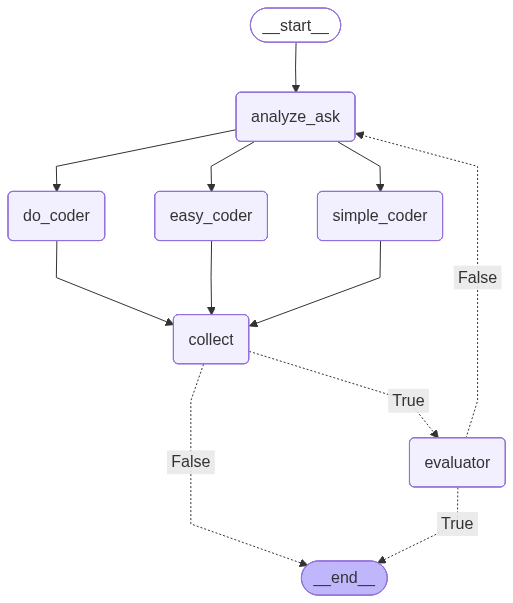

In [4]:
graph_builder = StateGraph(State)

graph_builder.add_node("analyze_ask",analyze_ask)
graph_builder.add_node("simple_coder",simple_coder)
graph_builder.add_node("do_coder",do_coder)
graph_builder.add_node("easy_coder",easy_coder)
graph_builder.add_node("collect",collect)
graph_builder.add_node("evaluator",evaluator)


graph_builder.add_edge(START,"analyze_ask")
graph_builder.add_edge("analyze_ask","simple_coder")
graph_builder.add_edge("analyze_ask","do_coder")
graph_builder.add_edge("analyze_ask","easy_coder")
graph_builder.add_edge("simple_coder","collect")
graph_builder.add_edge("do_coder","collect")
graph_builder.add_edge("easy_coder","collect")
graph_builder.add_conditional_edges("collect",has_three_codes,
    {True: "evaluator", False: END}
)
graph_builder.add_conditional_edges(
    "evaluator",
    evaluate_code,     
    {True: END, False: "analyze_ask"}
)

graph = graph_builder.compile()
graph

In [5]:
graph.invoke({
    "ask":"내이름을 출력하는 코드 짜줘"
})

{'ask': '내이름을 출력하는 코드 짜줘',
 'needs': [{'need': '당신의 이름을 출력하는 코드는 매우 간단한 프로그래밍 작업입니다. 대부분의 프로그래밍 언어에서 문자열을 출력하는 기능을 지원하므로 쉽게 구현할 수 있습니다. 몇 가지 인기 있는 프로그래밍 언어로 예제를 보여드리겠습니다. 여기서 예시로 이름을 "Alice"로 가정하겠습니다. \n\n1. **Python**\n   ```python\n   print("Alice")\n   ```\n\n2. **JavaScript**\n   ```javascript\n   console.log("Alice");\n   ```\n\n3. **Java**\n   ```java\n   public class Main {\n       public static void main(String[] args) {\n           System.out.println("Alice");\n       }\n   }\n   ```\n\n4. **C++**\n   ```cpp\n   #include <iostream>\n   using namespace std;\n\n   int main() {\n       cout << "Alice" << endl;\n       return 0;\n   }\n   ```\n\n5. **C**\n   ```c\n   #include <stdio.h>\n\n   int main() {\n       printf("Alice\\n");\n       return 0;\n   }\n   ```\n\n6. **Ruby**\n   ```ruby\n   puts "Alice"\n   ```\n\n7. **Go**\n   ```go\n   package main\n   import "fmt"\n   \n   func main() {\n       fmt.Println("Alice")\n   }\n   ```\n\n각 언어는 고유의 문법과 사용법을 가지고 있지만, 문자열을 출력하는 기능은 매